# 온라인 쇼핑몰 매출 관계분석
- 국가통계포털 https://kosis.kr/search/search.do
- 온라인쇼핑몰 판매매체별/상품군별거래액 검색
- 합계는 제외, 시점은 월별로 정리(단, 2020년도부터는 전기전자통신은 분리가됨)

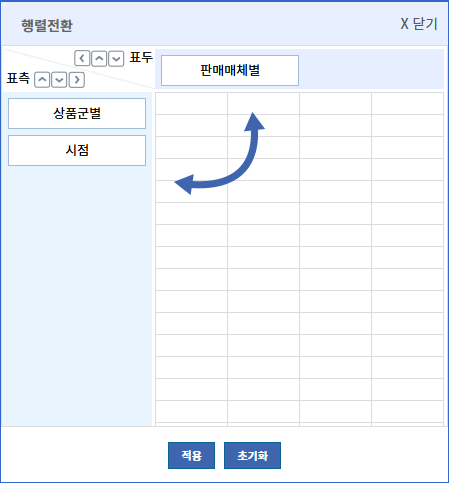

In [8]:
import pandas as pd

# 1. 파일 불러오기
file_path = './dataset/온라인쇼핑몰판매매체별상품군별거래액20260609.csv'
raw = pd.read_csv(file_path, encoding="EUC-KR")

# 2. 열 이름 수정
raw.columns = ['category', 'year', 'internet', 'mobile']

# 3. 데이터 전처리 (문자 제거 및 날짜 변환)
raw['year'] = raw['year'].astype(str).str.replace(' p)', '', regex=False)
raw['year'] = pd.to_datetime(raw['year'], format="%Y.%m", errors='coerce')

raw

,category,year,internet,mobile
0,컴퓨터 및 주변기기,2020-01-01,332810,273459
1,컴퓨터 및 주변기기,2020-02-01,358997,315829
2,컴퓨터 및 주변기기,2020-03-01,401374,357883
3,컴퓨터 및 주변기기,2020-04-01,388215,331746
4,컴퓨터 및 주변기기,2020-05-01,323924,290304
...,...,...,...,...
1743,기타,2025-12-01,83267,181591
1744,기타,2026-01-01,69691,188568
1745,기타,2026-02-01,69460,168825
1746,기타,2026-03-01,86497,201182


In [9]:
import pandas as pd

# 파일 경로 및 로드
file_path = './dataset/온라인쇼핑몰판매매체별상품군별거래액20260609.csv'
raw = pd.read_csv(file_path, encoding="EUC-KR")

# 열 이름 설정
raw.columns = ['category', 'year', 'internet', 'mobile']

In [10]:
# p라는 문자를 제거하는 방법
# 방법1
# raw['year'] = raw['year'].str.replace(" p)","")
# 방법2
raw['year'] = raw['year'].str.rstrip(' p)')
# 방법3
# raw['year'] = raw['year'].map( lambda x : x.rstrip(' p)'))
raw

,category,year,internet,mobile
0,컴퓨터 및 주변기기,2020.01,332810,273459
1,컴퓨터 및 주변기기,2020.02,358997,315829
2,컴퓨터 및 주변기기,2020.03,401374,357883
3,컴퓨터 및 주변기기,2020.04,388215,331746
4,컴퓨터 및 주변기기,2020.05,323924,290304
...,...,...,...,...
1743,기타,2025.12,83267,181591
1744,기타,2026.01,69691,188568
1745,기타,2026.02,69460,168825
1746,기타,2026.03,86497,201182


In [11]:
raw['year'] = pd.to_datetime(raw['year'], format="%Y.%m")
raw["category"].unique()

array(['컴퓨터 및 주변기기', '가전·전자·통신기기', '서적', '사무·문구', '의복', '신발', '가방',
       '패션용품 및 액세서리', '스포츠·레저용품', '화장품', '아동·유아용품', '음·식료품', '농축수산물',
       '생활용품', '자동차 및 자동차용품', '가구', '애완용품', '여행 및 교통서비스', '문화 및 레저서비스',
       '이쿠폰서비스', '음식서비스', '기타서비스', '기타'], dtype=object)

In [12]:
mydata = raw.copy()
mydata2 = mydata[mydata["category"].isin(['컴퓨터 및 주변기기', '자동차 및 자동차용품', '서적', '음식서비스', '여행 및 교통서비스', '문화 및 레저서비스', '스포츠·레저용품'])]
mydata2.sample(10)

,category,year,internet,mobile
1573,음식서비스,2024-06-01,31972,3016346
1319,여행 및 교통서비스,2022-04-01,395581,902337
669,스포츠·레저용품,2025-02-01,106566,246893
154,서적,2020-03-01,140036,120418
672,스포츠·레저용품,2025-05-01,139790,370076
1571,음식서비스,2024-04-01,30906,2784116
62,컴퓨터 및 주변기기,2025-03-01,366193,439505
1534,음식서비스,2021-03-01,59810,2052167
1345,여행 및 교통서비스,2024-06-01,686731,1965459
1341,여행 및 교통서비스,2024-02-01,727298,1882933


Text(0.2, 0.4, '한글')

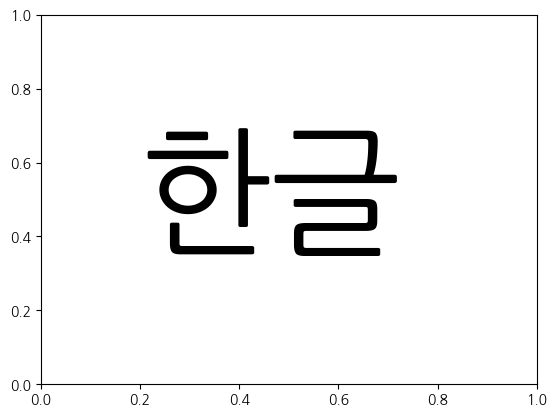

In [13]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

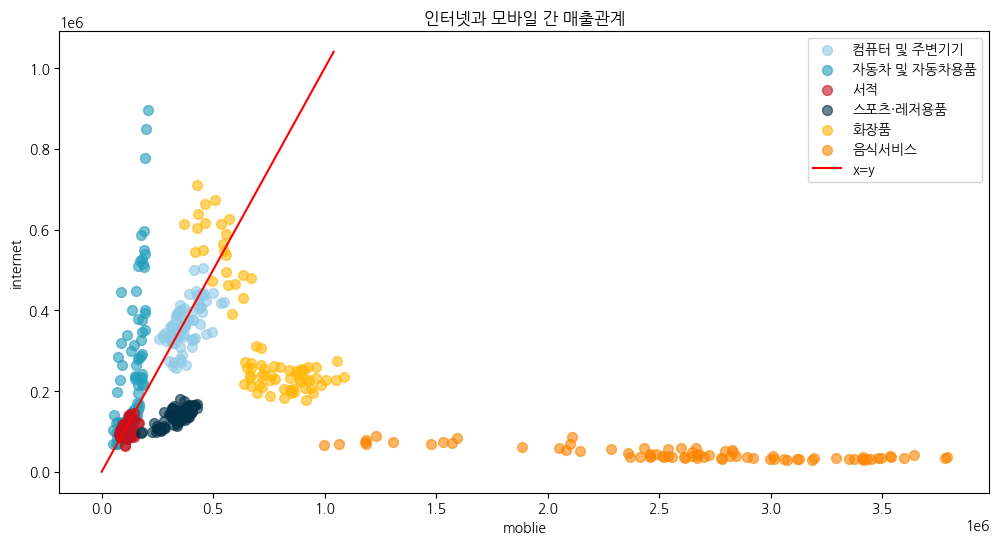

In [33]:
import matplotlib.pyplot as plt
import numpy as np

category = ['컴퓨터 및 주변기기', '자동차 및 자동차용품', '서적','스포츠·레저용품', '화장품','음식서비스']
colors = {'컴퓨터 및 주변기기':'#8ecae6', 
          '자동차 및 자동차용품':'#219ebc', 
          '서적':'#c1121f',
          '스포츠·레저용품':'#023047', 
          '화장품':'#ffb703',
          '음식서비스':'#fb8500'}

# 색상반환함수
def color_by(category_name):
    return colors.get(category_name,'black') # 기본값은 블랙

fig , ax = plt.subplots(figsize=(12,6))
for c in category:
    prod = mydata[ mydata["category"]== c]
    x = prod['mobile']
    y = prod['internet']
    ax.scatter(x,y, s=50, color=color_by(c), label=c, alpha=0.6)

xx = np.linspace(0, max(mydata2['internet']), 1000)
ax.plot(xx, xx, color='red', linestyle='-', label='x=y')

ax.set_title('인터넷과 모바일 간 매출관계')
ax.set_xlabel('moblie')
ax.set_ylabel('internet')
ax.legend()
plt.show()